# TCN Scaling Code

Notes:

* This notebook can run fixed LOSO experiments on 10, 20, and 30 tasks based on selected task config.
* The default 10-task subset is:
    * 11: "lift_suitcase_to_floor"
    * 12: "drink_from_glass"
    * 13: "answer_phone"
    * 16: "eat_apple"
    * 20: "use_key_unlock"
    * 21: "pour_water"
    * 23: "brush_teeth"
    * 24: "open_laptop"
    * 28: "open_door"
    * 29: "place_ball_in_basket"

* The TCN only uses current and past samples inside each window, which is better aligned with future live/streaming deployment.

* **Seeded version:** Python, NumPy, PyTorch, and DataLoader shuffling are seeded inside each LOSO fold so repeated runs are more reproducible. Overall raw and normalized confusion matrices are saved/displayed at the end.

## Imports

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib torch

import os, re
import random
# Must be set before torch is imported if strict deterministic CUDA algorithms are enabled later.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import itertools

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut



# Run the mvnx_file_reader.ipynb to load MVNX files
%run mvnx_file_reader.ipynb


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Segment labels: ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']
Segment IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
RightHand positions (first 5 frames): [[0.000326, -0.7332, 1.53858], [0.007659, -0.732989, 1.535369], [0.007659, -0.732989, 1.535369], [5.256316, 1.154359, 0.728047], [5.256684, 1.155001, 0.728414]]
normal
Data types: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'contacts', 'sensorFreeAcceleration'

### Globals

In [ ]:
# Task configurations
# Original 10-task subset used in the project
TASK_TO_LABEL_10 = {
    11: "lift_suitcase_to_floor",
    12: "drink_from_glass",
    13: "answer_phone",
    16: "eat_apple",
    20: "use_key_unlock",
    21: "pour_water",
    23: "brush_teeth",
    24: "open_laptop",
    28: "open_door",
    29: "place_ball_in_basket",
}

# Assumption for the 20-task run:
# keep the original 10 tasks and add the first 10 remaining task IDs.
EXTRA_20_TASK_IDS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

def make_generic_task_labels(task_ids):
    return {int(t): f"T{int(t):02d}" for t in sorted(task_ids)}

TASK_TO_LABEL_20 = {
    **make_generic_task_labels(EXTRA_20_TASK_IDS),
    **TASK_TO_LABEL_10,
}

TASK_TO_LABEL_30 = make_generic_task_labels(range(1, 31))
TASK_TO_LABEL_30.update(TASK_TO_LABEL_10)

TASK_CONFIGS = {
    "10tasks": TASK_TO_LABEL_10,
    "20tasks": TASK_TO_LABEL_20,
    "30tasks": TASK_TO_LABEL_30,
}

# change default task depending on what you want to run (e.g., "10tasks", "20tasks", "30tasks")
DEFAULT_TASK_CONFIG = "20tasks"

def set_task_config(task_config_name: str):
    global TASK_CONFIG_NAME, TASK_TO_LABEL, ALLOWED_TASKS, RESULTS_BASENAME

    if task_config_name not in TASK_CONFIGS:
        raise ValueError(f"Unknown task config: {task_config_name}. Expected one of {list(TASK_CONFIGS)}")

    TASK_CONFIG_NAME = str(task_config_name)
    TASK_TO_LABEL = dict(TASK_CONFIGS[TASK_CONFIG_NAME])
    ALLOWED_TASKS = set(TASK_TO_LABEL.keys())
    RESULTS_BASENAME = f"fixed_loso_4s_0p5s_4arm__{TASK_CONFIG_NAME}"

    print(f"Active task configuration: {TASK_CONFIG_NAME}")
    print(f"Tasks included ({len(ALLOWED_TASKS)}): {sorted(ALLOWED_TASKS)}")

set_task_config(DEFAULT_TASK_CONFIG)

LEFT_LIMB_SEGS  = ["LeftUpperArm", "LeftForeArm", "LeftHand", "LeftShoulder"]
RIGHT_LIMB_SEGS = ["RightUpperArm", "RightForeArm", "RightHand", "RightShoulder"]

def segments_for_tested_limb(limb: str):
    limb = str(limb).upper()
    return LEFT_LIMB_SEGS if limb == "L" else RIGHT_LIMB_SEGS

# You need to change DATA_ROOT to point to your local dataset path.
DATA_ROOT = "ULF_in_ADL"
# DATA_ROOT = "D:/UZH_data/ULF_in_ADL"

# Fixed experiment settings from the completed sweeps/ablations
CHANNELS = [
    "angularVelocity",
    "sensorFreeAcceleration",
]

WIN_LEN_S = 4.0   # seconds
STEP_S = 0.5      # seconds
MIN_OVERLAP_FRACTION = 0.5

# Fixed 4-arm-segment experiment only (no torso, no sweeps, no combinations)
ARM_SEGMENTS = ["UpperArm", "ForeArm", "Hand", "Shoulder"]

def expand_to_bilateral_arm_segments(base_arm_segments=None):
    if base_arm_segments is None:
        base_arm_segments = ARM_SEGMENTS

    canonical_to_left = {
        "UpperArm": "LeftUpperArm",
        "ForeArm": "LeftForeArm",
        "Hand": "LeftHand",
        "Shoulder": "LeftShoulder",
    }
    canonical_to_right = {
        "UpperArm": "RightUpperArm",
        "ForeArm": "RightForeArm",
        "Hand": "RightHand",
        "Shoulder": "RightShoulder",
    }

    selected_segments = []
    for name in base_arm_segments:
        if name not in canonical_to_left:
            raise ValueError(f"Unexpected arm segment name: {name}")
        selected_segments.extend([canonical_to_left[name], canonical_to_right[name]])
    return selected_segments

SELECTED_SEGMENTS = expand_to_bilateral_arm_segments(ARM_SEGMENTS)

# Cache settings
CACHE_DIR = "cached_datasets"
USE_DATASET_CACHE = True
FORCE_REBUILD_DATASET = False

# Result saving
RESULTS_DIR = "experiment_results"

# Training settings
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
KERNEL_SIZE = 5
TCN_CHANNELS = (64, 64, 128, 128)

# Early stopping
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.002
VAL_SIZE = 0.20
RANDOM_STATE = 42

# Reproducibility settings
GLOBAL_SEED = 42
# Keep strict deterministic algorithms off by default to avoid CUDA/cuBLAS warnings on some systems.
# Seeds are still set for Python, NumPy, PyTorch, and DataLoader shuffling.
DETERMINISTIC_TORCH = False

# LOSO evaluation settings
LOSO_MAX_FOLDS = None   # Keep None to run every subject
PLOT_FIRST_FOLD_CURVES = True
SAVE_PER_FOLD_CSV = True
SAVE_PER_SUBJECT_PREDICTIONS = True
SAVE_PER_SUBJECT_REPORTS = True


Active task configuration: 20tasks
Tasks included (20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 20, 21, 23, 24, 28, 29]


### File Helpers

Helper functions to find files, parse task from filename, and extract per-segment vectors

In [3]:
# Helper functions to find and parse MVNX files
def iter_mvnx_files(root: str):
    for r, _, files in os.walk(root):
        for fn in files:
            if fn.lower().endswith(".mvnx"):
                yield os.path.join(r, fn)

# Parses participant, task, limb, and rep from filename
def parse_meta_from_filename(filepath: str):
    """
    Expected example: H01_T01_L1.mvnx OR P02_T15_R3.mvnx
    Returns dict: participant, task(int), limb('L'/'R'), rep(int)
    """
    base = os.path.basename(filepath)

    m = re.match(r"^(?P<participant>[A-Za-z]\d{2})_T(?P<task>\d{2})_(?P<limb>[LRlr])(?P<rep>\d)\.mvnx$", base)
    if not m:
        return None

    participant = m.group("participant")
    task = int(m.group("task"))
    limb = m.group("limb").upper()
    rep = int(m.group("rep"))
    return {"participant": participant, "task": task, "limb": limb, "rep": rep}


# Functions to extract frame rate and channel data from MVNX dicts
def get_frame_rate_hz(mvnx_dict) -> float:
    # MVNX stores it on subject
    fr = mvnx_dict["mvnx"]["subject"].get("frameRate", None)
    if fr is None:
        raise ValueError("frameRate not found in mvnx['mvnx']['subject']")
    return float(fr)

def _as_list(x):
    if isinstance(x, list):
        return x
    if x is None:
        return []
    return [x]

def build_segment_index_map(mvnx_dict):
    segments = _as_list(mvnx_dict["mvnx"]["subject"]["segments"]["segment"])
    return {seg["label"]: i for i, seg in enumerate(segments)}

def build_sensor_index_map(mvnx_dict):
    sensors = _as_list(mvnx_dict["mvnx"]["subject"]["sensors"]["sensor"])
    return {sensor["label"]: i for i, sensor in enumerate(sensors)}

def build_joint_index_map(mvnx_dict):
    joints = _as_list(mvnx_dict["mvnx"]["subject"]["joints"]["joint"])
    return {joint["label"]: i for i, joint in enumerate(joints)}

SEGMENT_CHANNEL_SPECS = {
    "orientation": (build_segment_index_map, 4),
    "position": (build_segment_index_map, 3),
    "velocity": (build_segment_index_map, 3),
    "acceleration": (build_segment_index_map, 3),
    "angularVelocity": (build_segment_index_map, 3),
    "angularAcceleration": (build_segment_index_map, 3),
}

SENSOR_CHANNEL_SPECS = {
    "sensorFreeAcceleration": (build_sensor_index_map, 3),
    "sensorMagneticField": (build_sensor_index_map, 3),
    "sensorOrientation": (build_sensor_index_map, 4),
}

# For joint channels we map each tested segment to the most relevant joint on that limb.
JOINT_CHANNEL_SPECS = {
    "jointAngle": 3,
    "jointAngleXZY": 3,
}

LEFT_SEGMENT_TO_JOINT = {
    "LeftShoulder": "jLeftT4Shoulder",
    "LeftUpperArm": "jLeftShoulder",
    "LeftForeArm": "jLeftElbow",
    "LeftHand": "jLeftWrist",
}

RIGHT_SEGMENT_TO_JOINT = {
    "RightShoulder": "jRightT4Shoulder",
    "RightUpperArm": "jRightShoulder",
    "RightForeArm": "jRightElbow",
    "RightHand": "jRightWrist",
}

def get_segment_joint_label(segment_label: str, limb: str) -> str:
    limb = str(limb).upper()
    mapping = LEFT_SEGMENT_TO_JOINT if limb == "L" else RIGHT_SEGMENT_TO_JOINT
    if segment_label not in mapping:
        raise KeyError(f"No joint mapping defined for segment '{segment_label}' on limb '{limb}'.")
    return mapping[segment_label]

def _slice_labeled_vector(mvnx_dict, frame_dict, channel: str, label: str, index_builder, components: int) -> np.ndarray:
    label_map = index_builder(mvnx_dict)
    if label not in label_map:
        raise KeyError(f"Label '{label}' not found for channel '{channel}'. Available labels include: {list(label_map)[:8]} ...")

    vec = frame_dict.get(channel, None)
    if vec is None:
        raise KeyError(f"Channel '{channel}' not found in this frame.")

    arr = np.asarray(vec, dtype=np.float32).ravel()
    idx = label_map[label]
    start = components * idx
    end = start + components

    if end > arr.size:
        raise ValueError(
            f"Channel '{channel}' with label '{label}' expected slice [{start}:{end}] "
            f"but frame only has {arr.size} values."
        )
    return arr[start:end]

def get_channel_vector(mvnx_dict, frame_dict, segment_label: str, channel: str, limb: str) -> np.ndarray:
    """
    Channel-aware extractor.

    Uses:
    - segment indexing for segment-level channels
    - sensor indexing for sensor-level channels
    - joint indexing for joint-angle channels
    """
    if channel in SEGMENT_CHANNEL_SPECS:
        index_builder, components = SEGMENT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in SENSOR_CHANNEL_SPECS:
        index_builder, components = SENSOR_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, segment_label, index_builder, components)

    if channel in JOINT_CHANNEL_SPECS:
        joint_label = get_segment_joint_label(segment_label, limb)
        components = JOINT_CHANNEL_SPECS[channel]
        return _slice_labeled_vector(mvnx_dict, frame_dict, channel, joint_label, build_joint_index_map, components)

    raise KeyError(
        f"Unsupported channel '{channel}'. Add it to SEGMENT_CHANNEL_SPECS, "
        f"SENSOR_CHANNEL_SPECS, or JOINT_CHANNEL_SPECS."
    )

# Only keep frames where type="normal" (some files have "calibration" frames at the start that we want to ignore)
def only_normal_frames(mvnx: dict) -> list[dict]:
    frames = mvnx["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):
        frames = [frames]
    return [fr for fr in frames if str(fr.get("type", "")).lower() == "normal"]

# Generator for start/end indices of sliding windows over N samples
def window_indices(n_samples: int, win_len: int, step: int):
    s = 0
    while s + win_len <= n_samples:
        yield s, s + win_len
        s += step


In [4]:
# quick test
sample_paths = list(iter_mvnx_files(DATA_ROOT))[:5]
print("Found files (sample):")
for p in sample_paths:
    print(" ", os.path.basename(p), parse_meta_from_filename(p))

Found files (sample):
  P17_T02_L3.mvnx {'participant': 'P17', 'task': 2, 'limb': 'L', 'rep': 3}
  P17_T24_L2.mvnx {'participant': 'P17', 'task': 24, 'limb': 'L', 'rep': 2}
  P17_T28_R3.mvnx {'participant': 'P17', 'task': 28, 'limb': 'R', 'rep': 3}
  P17_T26_L1.mvnx {'participant': 'P17', 'task': 26, 'limb': 'L', 'rep': 1}
  P17_T01_L3.mvnx {'participant': 'P17', 'task': 1, 'limb': 'L', 'rep': 3}


Helpers for mvnx frame/channel extractions

In [5]:
# Build windows for one file, returning X_win (num_windows, win_len, num_channels), y_win (num_windows,), g_win (num_windows,)
def windows_file_cnn(filepath: str, win_len_s, step_s, channels=None, selected_segments=None):

    if channels is None:
        channels = CHANNELS

    meta = parse_meta_from_filename(filepath)
    if meta is None or meta["task"] not in ALLOWED_TASKS:
        return None

    mvnx = load_mvnx(filepath)
    frames = only_normal_frames(mvnx)
    if len(frames) < 10:
        return None

    frame_rate = float(mvnx["mvnx"]["subject"].get("frameRate", 0))
    win_len = max(int(round(win_len_s * frame_rate)), 5)
    step = max(int(round(step_s * frame_rate)), 1)

    default_segments = segments_for_tested_limb(meta["limb"])
    if selected_segments is None:
        segments = default_segments
    else:
        selected_segments = [str(seg) for seg in selected_segments]
        available = set(default_segments)
        segments = [seg for seg in selected_segments if seg in available]
        if len(segments) == 0:
            raise ValueError(
                f"No valid segments selected for limb {meta['limb']}. "
                f"Requested: {selected_segments} | Available: {default_segments}"
            )

    N = len(frames)

    # Precompute channel arrays for each segment. The feature width depends on channel type:
    # xyz channels -> 3, quaternion channels -> 4.
    data = {}
    feature_dims = {}
    for seg in segments:
        for ch in channels:
            first_vec = get_channel_vector(mvnx, frames[0], seg, ch, meta["limb"])
            D = int(np.asarray(first_vec).size)
            arr = np.zeros((N, D), dtype=np.float32)
            arr[0] = first_vec
            for i in range(1, N):
                arr[i] = get_channel_vector(mvnx, frames[i], seg, ch, meta["limb"])
            data[(ch, seg)] = arr
            feature_dims[(ch, seg)] = D

    X_win, y_win, g_win = [], [], []
    for a, b in window_indices(N, win_len, step):
        cols = []
        for seg in segments:
            for ch in channels:
                cols.append(data[(ch, seg)][a:b])   # (T,D)
        Xw = np.concatenate(cols, axis=1)          # (T, C_total)
        X_win.append(Xw)
        y_win.append(TASK_TO_LABEL[meta["task"]])
        g_win.append(meta["participant"])

    if not X_win:
        return None

    return (
        np.stack(X_win, axis=0).astype(np.float32),
        np.asarray(y_win),
        np.asarray(g_win),
    )


## Building Dataset
Building a fixed post-arm-study dataset using:

- channels: `angularVelocity`, `sensorFreeAcceleration`
- window length: **4.0 s**
- step size: **0.5 s**

Each run keeps the tested-limb **UpperArm, ForeArm, Hand, and Shoulder** segments and then adds a combination of torso segments.


In [6]:
# Dataset caching helpers
def _safe_name(txt: str):
    txt = str(txt)
    txt = re.sub(r"[^A-Za-z0-9_.-]+", "-", txt)
    return txt.strip("-") or "default"

def canonical_segment_order(selected_segments):
    if selected_segments is None:
        return None
    return [str(seg) for seg in selected_segments]

def make_dataset_cache_path(
    root: str,
    channels,
    win_len_s: float,
    step_s: float,
    selected_segments=None,
    allowed_tasks=None,
    cache_dir: str = CACHE_DIR,
):
    os.makedirs(cache_dir, exist_ok=True)

    root_name = _safe_name(os.path.basename(os.path.normpath(root)) or "dataset")
    channel_name = _safe_name("_".join(channels))
    if selected_segments is None:
        segment_name = "default-tested-limb"
    else:
        segment_name = _safe_name("_".join(canonical_segment_order(selected_segments)))
    task_name = "alltasks" if allowed_tasks is None else _safe_name("-".join(map(str, sorted(allowed_tasks))))

    filename = (
        f"dataset_{root_name}"
        f"__ch-{channel_name}"
        f"__seg-{segment_name}"
        f"__win-{win_len_s:g}s"
        f"__step-{step_s:g}s"
        f"__tasks-{task_name}.npz"
    )
    return os.path.join(cache_dir, filename)

# Build the full dataset by iterating over all files and concatenating results
def build_dataset(root: str, win_len_s, step_s, channels=None, selected_segments=None):
    if channels is None:
        channels = CHANNELS

    X_list, y_list, g_list = [], [], []
    kept = 0
    skipped = 0

    for fp in iter_mvnx_files(root):
        meta = parse_meta_from_filename(fp)
        if meta is None:
            continue
        if meta["task"] not in ALLOWED_TASKS:
            continue

        try:
            out = windows_file_cnn(
                fp,
                win_len_s=win_len_s,
                step_s=step_s,
                channels=channels,
                selected_segments=selected_segments,
            )
        except Exception as e:
            skipped += 1
            print(f"Skipping {os.path.basename(fp)} due to extraction/build error: {e}")
            continue

        if out is None:
            skipped += 1
            continue

        Xw, yw, gw = out
        X_list.append(Xw)
        y_list.append(yw)
        g_list.append(gw)
        kept += 1

    if not X_list:
        raise RuntimeError("No windows were built. Check parsing/task filters/DATA_ROOT.")

    X = np.concatenate(X_list, axis=0)   # (N, T, C)
    y = np.concatenate(y_list, axis=0)   # (N,)
    g = np.concatenate(g_list, axis=0)   # (N,)

    print(f"Kept files: {kept} | Skipped files (allowed but failed): {skipped}")
    print("X:", X.shape, "y:", y.shape, "groups:", g.shape)

    return X, y, g

def load_or_build_dataset(root: str, win_len_s, step_s, channels, selected_segments=None, use_cache=True, force_rebuild=False):
    cache_path = make_dataset_cache_path(
        root=root,
        channels=channels,
        win_len_s=win_len_s,
        step_s=step_s,
        selected_segments=selected_segments,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    if use_cache and os.path.exists(cache_path) and not force_rebuild:
        print(f"Loading cached dataset from: {cache_path}")
        cached = np.load(cache_path, allow_pickle=True)
        X = cached["X"]
        y = cached["y"]
        g = cached["groups"]
        return X, y, g, cache_path

    print("No cached dataset found. Building dataset from MVNX files...")
    X, y, g = build_dataset(
        root,
        win_len_s=win_len_s,
        step_s=step_s,
        channels=channels,
        selected_segments=selected_segments,
    )

    if use_cache:
        np.savez_compressed(
            cache_path,
            X=X.astype(np.float32),
            y=y,
            groups=g,
            channels=np.array(channels, dtype=object),
            selected_segments=np.array(
                canonical_segment_order(selected_segments) if selected_segments is not None else [],
                dtype=object
            ),
            win_len_s=np.array([win_len_s], dtype=np.float32),
            step_s=np.array([step_s], dtype=np.float32),
        )
        print(f"Saved dataset cache to: {cache_path}")

    return X, y, g, cache_path

def summarize_dataset(X, y, groups, prefix="Segment ablation run"):
    print(f"{prefix} dataset loaded.")
    print("Dataset shape:", X.shape)
    print("Unique subjects:", len(set(groups)))
    vals, cnts = np.unique(y, return_counts=True)
    print("Class counts:", dict(zip(vals, cnts)))
    print("Example window shape (T,C):", X[0].shape)


### Normalization

Different normalization from SVM

In [7]:
# IMPORTANT:
# Do NOT normalize before LOSO splitting. That would let the held-out subject
# influence scaling. Instead, fit normalization on the training fold only and
# apply it to val/test inside each fold.

def fit_channel_zscore(X: np.ndarray, eps: float = 1e-8):
    """
    Fit one global z-score per feature channel using TRAINING WINDOWS ONLY.

    X: (N, T, C)
    Returns:
        mu: (C,)
        sd: (C,)
    """
    pooled = X.reshape(-1, X.shape[-1]).astype(np.float32)
    mu = pooled.mean(axis=0)
    sd = pooled.std(axis=0)
    sd = np.maximum(sd, eps)
    return mu, sd

def apply_channel_zscore(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """Apply pre-fit channel-wise z-score to (N, T, C)."""
    return ((X.astype(np.float32) - mu) / sd).astype(np.float32)

print("Normalization helpers defined.")
print("Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()")
print("via load_or_build_dataset(...), one window/step configuration at a time.")


Normalization helpers defined.
Dataset arrays (X, y, groups) are loaded later inside run_windowing_study()
via load_or_build_dataset(...), one window/step configuration at a time.


### Note on dataset creation and caching

This notebook runs a fixed LOSO study at **4.0 s** windows and **0.5 s** steps using:

- channels: `angularVelocity`, `sensorFreeAcceleration`
- tested-limb 4-arm segment set: `UpperArm`, `ForeArm`, `Hand`, `Shoulder`

It can run three task scopes:

- **10 tasks**: the original project subset
- **20 tasks**: the original 10 plus 10 added tasks
- **30 tasks**: all tasks in the dataset

Each task scope gets its own dataset cache and its own results stem so runs do not overwrite each other.


## Train and Evaluate



Train/test split by subject and encode labels

In [8]:
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
import hashlib
from collections import defaultdict
from itertools import product
from datetime import datetime

def encode_labels(y: np.ndarray):
    labels = sorted(list(set(y)))
    lab2i = {lab:i for i, lab in enumerate(labels)}
    i2lab = {i:lab for lab,i in lab2i.items()}
    y_i = np.array([lab2i[v] for v in y], dtype=np.int64)
    return labels, lab2i, i2lab, y_i

def make_grouped_train_val_split(groups_train: np.ndarray, val_size: float = VAL_SIZE, random_state: int = RANDOM_STATE):
    """
    Creates a validation split using training subjects only.
    This is used INSIDE each LOSO fold for early stopping.
    """
    unique_subjects = np.unique(groups_train)

    if len(unique_subjects) < 2:
        raise ValueError("Need at least 2 training subjects to create a validation split.")

    if len(unique_subjects) == 2:
        # Fallback: keep one subject for train and one for validation
        val_subject = unique_subjects[-1]
        val_idx = np.where(groups_train == val_subject)[0]
        train_idx = np.where(groups_train != val_subject)[0]
        return train_idx, val_idx

    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(np.zeros(len(groups_train)), groups=groups_train))
    return train_idx, val_idx

def hash_array(a: np.ndarray) -> str:
    h = hashlib.md5()
    h.update(a.tobytes())
    return h.hexdigest()

def report_split_integrity(name_a, X_a, g_a, idx_a, name_b, X_b, g_b, idx_b):
    overlap = set(g_a) & set(g_b)
    if overlap:
        print(f"WARNING: Subject(s) in both {name_a} and {name_b}: {overlap}")
    else:
        print(f"No subject overlap detected between {name_a} and {name_b}.")

    hashes_a = {hash_array(X_a[i]): idx_a[i] for i in range(len(X_a))}
    hashes_b = {hash_array(X_b[i]): idx_b[i] for i in range(len(X_b))}
    common = set(hashes_a.keys()) & set(hashes_b.keys())
    print(f"Identical windows in {name_a}/{name_b}: {len(common)}")
    if common:
        for h in list(common)[:5]:
            print(f"Example identical window - {name_a} idx: {hashes_a[h]} | {name_b} idx: {hashes_b[h]}")

def build_loso_splits(X, y_i, groups, max_folds=None):
    logo = LeaveOneGroupOut()
    all_loso_splits = list(logo.split(X, y_i, groups=groups))
    if max_folds is not None:
        all_loso_splits = all_loso_splits[:max_folds]
    return all_loso_splits

def window_overlap_fraction(win_len_s: float, step_s: float) -> float:
    return 1.0 - (step_s / win_len_s)

def is_valid_window_step_combo(win_len_s: float, step_s: float, min_overlap_fraction: float = MIN_OVERLAP_FRACTION) -> bool:
    if step_s <= 0 or win_len_s <= 0:
        return False
    if step_s > win_len_s:
        return False
    return window_overlap_fraction(win_len_s, step_s) >= min_overlap_fraction

def make_windowing_grid(window_lengths=None, step_sizes=None, min_overlap_fraction: float = MIN_OVERLAP_FRACTION):
    window_lengths = SWEEP_WINDOW_LENGTHS if window_lengths is None else window_lengths
    step_sizes = SWEEP_STEP_SIZES if step_sizes is None else step_sizes

    combos = []
    for win_len_s, step_s in product(window_lengths, step_sizes):
        overlap = window_overlap_fraction(win_len_s, step_s)
        if is_valid_window_step_combo(win_len_s, step_s, min_overlap_fraction=min_overlap_fraction):
            combos.append({
                "win_len_s": float(win_len_s),
                "step_s": float(step_s),
                "overlap_fraction": float(overlap),
            })
        else:
            print(f"Skipping invalid combo: win={win_len_s}, step={step_s}, overlap={overlap:.3f}")
    return combos

def ensure_results_dir(results_dir: str = RESULTS_DIR):
    os.makedirs(results_dir, exist_ok=True)
    return results_dir

def make_results_stem(study_name: str, win_len_s: float, step_s: float, results_dir: str = RESULTS_DIR):
    ensure_results_dir(results_dir)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_study_name = _safe_name(study_name)

    base = f"{safe_study_name}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    # Keep filenames short enough for Windows path limits.
    max_base_len = 110
    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        truncated = safe_study_name[:40].rstrip("-_.")
        base = f"{truncated}__{name_hash}__win-{win_len_s:g}s__step-{step_s:g}s__{timestamp}"

    if len(base) > max_base_len:
        name_hash = hashlib.md5(safe_study_name.encode("utf-8")).hexdigest()[:8]
        base = f"run__{name_hash}__w{win_len_s:g}s__s{step_s:g}s__{timestamp}"

    return os.path.join(results_dir, base)


Simple TCN dataset and model


In [9]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

class WindowDataset(Dataset):
    def __init__(self, X, y_int):
        # Convert (N, T, C) -> (N, C, T) for Conv1d
        self.X = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)
        self.y = torch.tensor(y_int, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class Chomp1d(nn.Module):
    """
    Removes the extra right-side padding so the convolution is causal:
    output[t] depends only on x[:t].
    """
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # causal

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_channels, out_channels, kernel_size,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class SimpleTCN(nn.Module):
    def __init__(self, in_channels, n_classes, channels=TCN_CHANNELS, kernel_size=KERNEL_SIZE, dropout=DROPOUT):
        super().__init__()

        layers = []
        prev_channels = in_channels
        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(prev_channels, n_classes)

    def forward(self, x):
        z = self.tcn(x)
        z = self.pool(z).squeeze(-1)
        return self.classifier(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_global_seed(seed: int = GLOBAL_SEED, deterministic: bool = DETERMINISTIC_TORCH):
    """Set Python/NumPy/PyTorch seeds so baseline training is more repeatable.

    Exact reproducibility can still depend on GPU, CUDA, and PyTorch versions.
    """
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # These cuDNN flags reduce nondeterminism without forcing all deterministic algorithms.
    torch.backends.cudnn.deterministic = bool(deterministic)
    torch.backends.cudnn.benchmark = False

    if deterministic:
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)

def make_torch_generator(seed=None):
    """Create a seeded torch.Generator for deterministic DataLoader shuffling."""
    if seed is None:
        return None
    g = torch.Generator()
    g.manual_seed(int(seed))
    return g

set_global_seed(GLOBAL_SEED)
print(f"Global seed set to {GLOBAL_SEED}; deterministic_torch={DETERMINISTIC_TORCH}")

def make_loaders(X_train, y_train_i, X_val, y_val_i, X_test, y_test_i, seed=None):
    train_ds = WindowDataset(X_train, y_train_i)
    val_ds   = WindowDataset(X_val, y_val_i)
    test_ds  = WindowDataset(X_test, y_test_i)

    train_generator = make_torch_generator(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True, drop_last=False, generator=train_generator)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE_EVAL, shuffle=False, drop_last=False)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

def build_model_and_training_objects(in_channels: int, y_train_i: np.ndarray, n_classes: int):
    """
    Build the TCN, class-weighted loss, and optimizer.

    n_classes is passed in from the current experiment instead of using a global
    `labels` variable. This prevents stale class counts from earlier runs.
    """
    model = SimpleTCN(
        in_channels=in_channels,
        n_classes=n_classes,
    ).to(device)

    y_train_i = np.asarray(y_train_i, dtype=int)
    if y_train_i.size > 0 and y_train_i.max() >= n_classes:
        raise ValueError(
            f"Found encoded label {y_train_i.max()} but n_classes={n_classes}. "
            "This usually means the label encoder and model class count are mismatched."
        )

    counts = np.bincount(y_train_i, minlength=n_classes).astype(np.float32)
    w = counts.sum() / (counts + 1e-6)
    w = w / w.mean()
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    return model, criterion, optimizer

def eval_model(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def run_eval_loss_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            pred = torch.argmax(logits, dim=1)
            ys.append(yb.cpu().numpy())
            ps.append(pred.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

print("TCN classes and helper functions are ready.")


Using device: cuda
Global seed set to 42; deterministic_torch=False
TCN classes and helper functions are ready.


### Train and evaluate


##############################################################################################################
RUNNING FIXED LOSO EXPERIMENT FOR: 20tasks
##############################################################################################################
Active task configuration: 20tasks
Tasks included (20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 20, 21, 23, 24, 28, 29]
Loading cached dataset from: cached_datasets/dataset_ULF_in_ADL__ch-angularVelocity_sensorFreeAcceleration__seg-LeftUpperArm_RightUpperArm_LeftForeArm_RightForeArm_LeftHand_RightHand_LeftShoulder_RightShoulder__win-4s__step-0.5s__tasks-1-2-3-4-5-6-7-8-9-10-11-12-13-16-20-21-23-24-28-29.npz
Fixed 4-arm LOSO dataset [20tasks] dataset loaded.
Dataset shape: (67691, 240, 24)
Unique subjects: 25
Class counts: {np.str_('T01'): np.int64(8126), np.str_('T02'): np.int64(8190), np.str_('T03'): np.int64(8159), np.str_('T04'): np.int64(8171), np.str_('T05'): np.int64(8185), np.str_('T06'): np.int64(8101), np.st

,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,7,P03,4.0,0.5,0.875,63768,3544,379,19,5,20,0.776806,0.984169,0.980183
1,4,H04,4.0,0.5,0.875,63872,3544,275,19,5,20,0.766648,0.978182,0.885832
2,17,P19,4.0,0.5,0.875,63073,4363,255,19,5,20,0.682558,0.968627,0.739240
3,24,P29,4.0,0.5,0.875,63699,3584,408,19,5,13,0.710658,0.946078,0.946012
4,22,P25,4.0,0.5,0.875,63615,3584,492,19,5,17,0.743862,0.941057,0.806303
5,3,H03,4.0,0.5,0.875,63719,3544,428,19,5,20,0.771163,0.934579,0.661049
6,13,P10,4.0,0.5,0.875,62883,4363,445,19,5,18,0.680495,0.932584,0.623958
7,2,H02,4.0,0.5,0.875,63881,3544,266,19,5,18,0.761287,0.917293,0.828725
8,15,P16,4.0,0.5,0.875,62709,4363,619,19,5,16,0.666055,0.907916,0.557975
9,19,P21,4.0,0.5,0.875,63376,3767,548,19,5,14,0.680382,0.886861,0.605802



LOSO SUMMARY
Overall window-level accuracy: 0.1914
Overall window-level macro F1: 0.2565
Mean fold accuracy: 0.7848 ± 0.2051
Mean fold macro F1: 0.5861 ± 0.2159
Saved overall confusion matrix CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__overall_confusion_matrix.csv
Saved normalized overall confusion matrix CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__overall_confusion_matrix_normalized.csv


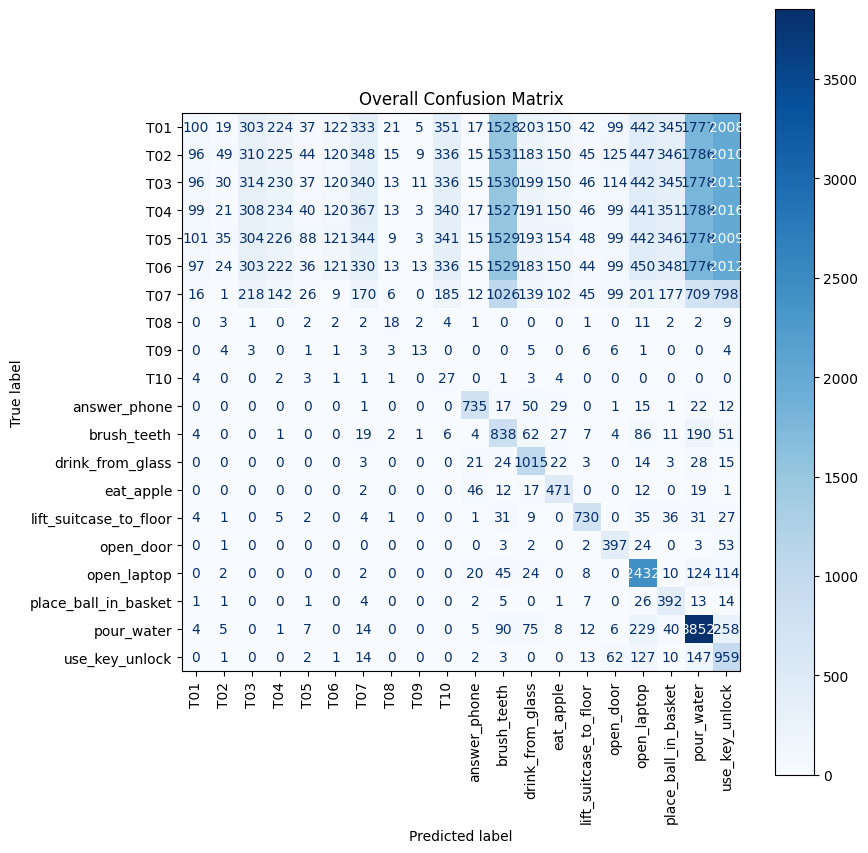

Saved overall confusion matrix PNG: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__overall_confusion_matrix.png


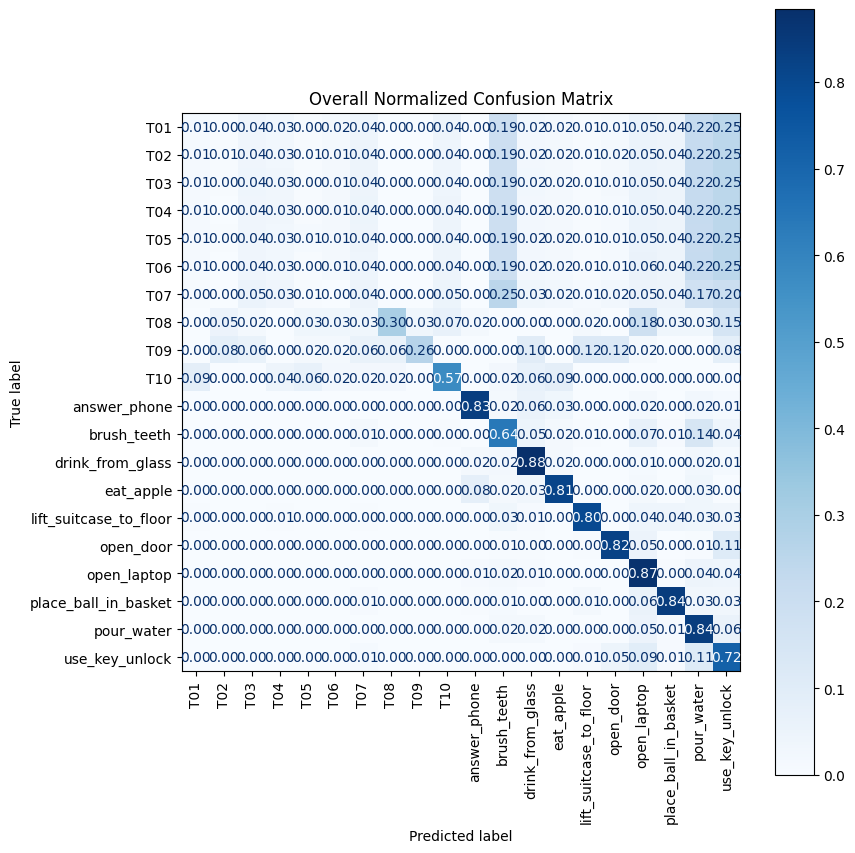

Saved overall normalized confusion matrix PNG: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__overall_confusion_matrix_normalized.png
Saved summary CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__summary.csv
Saved per-fold CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__folds.csv
Saved all-subject prediction CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__arm-Up__c440d7b3__win-4s__step-0.5s__20260506_111037__all_subject_predictions.csv


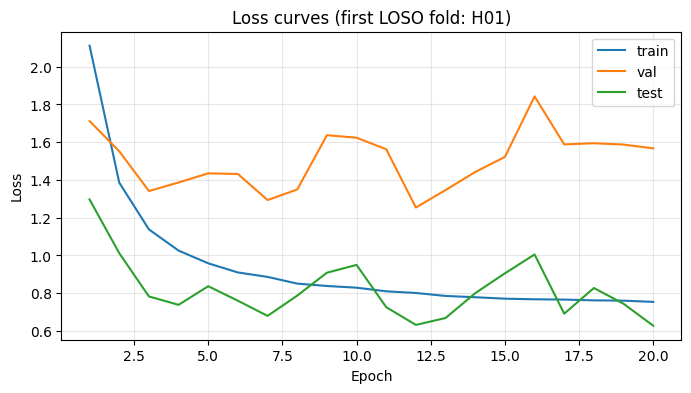

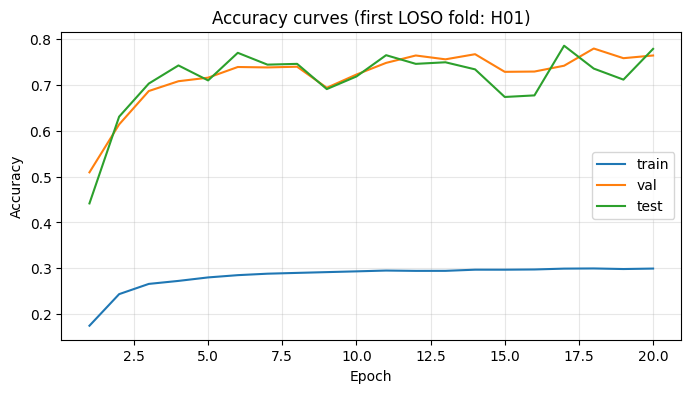


Fixed LOSO experiment complete for 20tasks.


,study_name,task_config_name,win_len_s,step_s,overlap_fraction,channels_used,selected_segments,n_total_windows,n_subjects,n_classes,...,overall_acc,overall_macro_f1,mean_fold_acc,std_fold_acc,mean_fold_macro_f1,std_fold_macro_f1,mean_epochs_ran,mean_best_val_acc,arm_segments,dataset_cache_path
0,fixed_loso_4s_0p5s_4arm__20tasks__arm-UpperArm...,20tasks,4.0,0.5,0.875,angularVelocity|sensorFreeAcceleration,LeftUpperArm|RightUpperArm|LeftForeArm|RightFo...,67691,25,20,...,0.191384,0.256525,0.784767,0.205086,0.586134,0.215871,17.2,0.718253,UpperArm|ForeArm|Hand|Shoulder,cached_datasets/dataset_ULF_in_ADL__ch-angular...



20-task LOSO summary:


,study_name,task_config_name,win_len_s,step_s,overlap_fraction,channels_used,selected_segments,n_total_windows,n_subjects,n_classes,...,overall_acc,overall_macro_f1,mean_fold_acc,std_fold_acc,mean_fold_macro_f1,std_fold_macro_f1,mean_epochs_ran,mean_best_val_acc,arm_segments,dataset_cache_path
0,fixed_loso_4s_0p5s_4arm__20tasks__arm-UpperArm...,20tasks,4.0,0.5,0.875,angularVelocity|sensorFreeAcceleration,LeftUpperArm|RightUpperArm|LeftForeArm|RightFo...,67691,25,20,...,0.191384,0.256525,0.784767,0.205086,0.586134,0.215871,17.2,0.718253,UpperArm|ForeArm|Hand|Shoulder,cached_datasets/dataset_ULF_in_ADL__ch-angular...


Saved 20-task summary CSV: experiment_results/fixed_loso_4s_0p5s_4arm__20tasks__summary_only.csv

--------------------------------------------------------------------------------------------------------------
SUBJECT RANKING FOR: 20tasks
--------------------------------------------------------------------------------------------------------------


,fold,test_subject,win_len_s,step_s,overlap_fraction,n_train_windows,n_val_windows,n_test_windows,n_train_subjects,n_val_subjects,epochs_ran,best_val_acc,test_acc,test_macro_f1
0,7,P03,4.0,0.5,0.875,63768,3544,379,19,5,20,0.776806,0.984169,0.980183
1,4,H04,4.0,0.5,0.875,63872,3544,275,19,5,20,0.766648,0.978182,0.885832
2,17,P19,4.0,0.5,0.875,63073,4363,255,19,5,20,0.682558,0.968627,0.739240
3,24,P29,4.0,0.5,0.875,63699,3584,408,19,5,13,0.710658,0.946078,0.946012
4,22,P25,4.0,0.5,0.875,63615,3584,492,19,5,17,0.743862,0.941057,0.806303
5,3,H03,4.0,0.5,0.875,63719,3544,428,19,5,20,0.771163,0.934579,0.661049
6,13,P10,4.0,0.5,0.875,62883,4363,445,19,5,18,0.680495,0.932584,0.623958
7,2,H02,4.0,0.5,0.875,63881,3544,266,19,5,18,0.761287,0.917293,0.828725
8,15,P16,4.0,0.5,0.875,62709,4363,619,19,5,16,0.666055,0.907916,0.557975
9,19,P21,4.0,0.5,0.875,63376,3767,548,19,5,14,0.680382,0.886861,0.605802


Best held-out subject: P03
Worst held-out subject: P28

Classification report for best subject:


,test_subject,label_or_avg,precision,recall,f1-score,support
0,P03,T01,0.000000,0.000000,0.000000,0.000000
1,P03,T02,0.000000,0.000000,0.000000,0.000000
2,P03,T03,0.000000,0.000000,0.000000,0.000000
3,P03,T04,0.000000,0.000000,0.000000,0.000000
4,P03,T05,0.000000,0.000000,0.000000,0.000000
5,P03,T06,0.000000,0.000000,0.000000,0.000000
6,P03,T07,0.000000,0.000000,0.000000,0.000000
7,P03,T08,0.000000,0.000000,0.000000,0.000000
8,P03,T09,0.000000,0.000000,0.000000,0.000000
9,P03,T10,0.000000,0.000000,0.000000,0.000000



Classification report for worst subject:


,test_subject,label_or_avg,precision,recall,f1-score,support
0,P28,T01,0.161616,0.011914,0.022191,8058.000000
1,P28,T02,0.166667,0.002234,0.004409,8058.000000
2,P28,T03,0.148968,0.037602,0.060048,8058.000000
3,P28,T04,0.150713,0.027550,0.046585,8058.000000
4,P28,T05,0.153846,0.004468,0.008683,8058.000000
5,P28,T06,0.164609,0.014892,0.027313,8058.000000
6,P28,T07,0.073034,0.038719,0.050608,4029.000000
7,P28,T08,0.000000,0.000000,0.000000,0.000000
8,P28,T09,0.000000,0.000000,0.000000,0.000000
9,P28,T10,0.000000,0.000000,0.000000,3.000000


In [ ]:
from sklearn.metrics import f1_score, classification_report

def run_loso_experiment(
    X,
    y,
    groups,
    study_name: str,
    win_len_s: float,
    step_s: float,
    channels_used=None,
    selected_segments=None,
    plot_first_fold_curves: bool = PLOT_FIRST_FOLD_CURVES,
    loso_max_folds=LOSO_MAX_FOLDS,
    save_per_fold_csv: bool = SAVE_PER_FOLD_CSV,
    save_per_subject_predictions: bool = SAVE_PER_SUBJECT_PREDICTIONS,
    save_per_subject_reports: bool = SAVE_PER_SUBJECT_REPORTS,
    results_dir: str = RESULTS_DIR,
):
    labels, lab2i, i2lab, y_i = encode_labels(y)
    all_loso_splits = build_loso_splits(X, y_i, groups, max_folds=loso_max_folds)

    print(f"Total LOSO folds to run: {len(all_loso_splits)}")
    print("Classes:", labels)
    print("Subjects:", sorted(np.unique(groups)))

    fold_rows = []
    prediction_rows = []
    per_subject_reports = {}
    all_y_true = []
    all_y_pred = []
    first_fold_history = None

    results_stem = make_results_stem(
        study_name=study_name,
        win_len_s=win_len_s,
        step_s=step_s,
        results_dir=results_dir,
    )

    for fold_idx, (trainval_idx, test_idx) in enumerate(all_loso_splits, start=1):
        held_out_subject = np.unique(groups[test_idx])
        if len(held_out_subject) != 1:
            raise RuntimeError("LOSO fold should contain exactly one held-out subject.")
        held_out_subject = held_out_subject[0]

        print("=" * 90)
        print(f"LOSO fold {fold_idx}/{len(all_loso_splits)} | test subject: {held_out_subject}")

        # Deterministic fold-level seed: controls model initialization, PyTorch RNG, and DataLoader shuffling.
        fold_seed = GLOBAL_SEED + fold_idx
        set_global_seed(fold_seed)
        print(f"Fold seed: {fold_seed}")

        X_trainval_raw, X_test_raw = X[trainval_idx], X[test_idx]
        y_trainval_i, y_test_i = y_i[trainval_idx], y_i[test_idx]
        y_test_labels = y[test_idx]
        g_trainval, g_test = groups[trainval_idx], groups[test_idx]

        train_sub_idx, val_sub_idx = make_grouped_train_val_split(
            g_trainval,
            val_size=VAL_SIZE,
            random_state=RANDOM_STATE
        )

        X_train_raw, X_val_raw = X_trainval_raw[train_sub_idx], X_trainval_raw[val_sub_idx]
        y_train_i, y_val_i = y_trainval_i[train_sub_idx], y_trainval_i[val_sub_idx]
        g_train, g_val = g_trainval[train_sub_idx], g_trainval[val_sub_idx]

        print(f"Train subjects: {sorted(np.unique(g_train))}")
        print(f"Val subjects:   {sorted(np.unique(g_val))}")
        print(f"Test subject:   {sorted(np.unique(g_test))}")

        mu, sd = fit_channel_zscore(X_train_raw)
        X_train = apply_channel_zscore(X_train_raw, mu, sd)
        X_val   = apply_channel_zscore(X_val_raw, mu, sd)
        X_test  = apply_channel_zscore(X_test_raw, mu, sd)

        report_split_integrity(
            "train", X_train, g_train, trainval_idx[train_sub_idx],
            "val", X_val, g_val, trainval_idx[val_sub_idx]
        )
        report_split_integrity(
            "train", X_train, g_train, trainval_idx[train_sub_idx],
            "test", X_test, g_test, test_idx
        )
        report_split_integrity(
            "val", X_val, g_val, trainval_idx[val_sub_idx],
            "test", X_test, g_test, test_idx
        )

        train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(
            X_train, y_train_i, X_val, y_val_i, X_test, y_test_i, seed=fold_seed + 10_000
        )

        model, criterion, optimizer = build_model_and_training_objects(
            in_channels=train_ds.X.shape[1],
            y_train_i=y_train_i,
            n_classes=len(labels),
        )

        train_losses, val_losses, test_losses = [], [], []
        train_accs, val_accs, test_accs = [], [], []

        epochs_ran = 0
        best_val_acc = -1.0
        best_state = None
        patience_counter = 0

        for epoch in range(1, EPOCHS + 1):
            epochs_ran = epoch
            model.train()
            total_loss = 0.0
            ys, ps = [], []

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item() * xb.size(0)
                pred = torch.argmax(logits, dim=1)
                ys.append(yb.cpu().numpy())
                ps.append(pred.detach().cpu().numpy())

            train_loss = total_loss / len(train_loader.dataset)
            train_acc = accuracy_score(np.concatenate(ys), np.concatenate(ps))

            val_loss, val_acc = run_eval_loss_acc(model, val_loader, criterion)
            test_loss, test_acc = run_eval_loss_acc(model, test_loader, criterion)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)

            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

            improvement = val_acc - best_val_acc
            if improvement > EARLY_STOPPING_MIN_DELTA:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                print(
                    f"  No validation improvement greater than {EARLY_STOPPING_MIN_DELTA:.4f}. "
                    f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}"
                )
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        y_true_fold, y_pred_fold = eval_model(model, test_loader)
        fold_acc = accuracy_score(y_true_fold, y_pred_fold)
        fold_macro_f1 = f1_score(y_true_fold, y_pred_fold, average="macro", zero_division=0)

        report_dict = classification_report(
            y_true_fold,
            y_pred_fold,
            labels=np.arange(len(labels)),
            target_names=labels,
            output_dict=True,
            zero_division=0,
        )
        report_df = pd.DataFrame(report_dict).transpose().reset_index().rename(columns={"index": "label_or_avg"})
        report_df.insert(0, "test_subject", held_out_subject)
        per_subject_reports[held_out_subject] = report_df

        pred_df = pd.DataFrame({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "window_global_index": test_idx,
            "true_label": [i2lab[i] for i in y_true_fold],
            "pred_label": [i2lab[i] for i in y_pred_fold],
            "true_label_int": y_true_fold,
            "pred_label_int": y_pred_fold,
            "correct": y_true_fold == y_pred_fold,
        })
        prediction_rows.append(pred_df)

        fold_rows.append({
            "fold": fold_idx,
            "test_subject": held_out_subject,
            "win_len_s": win_len_s,
            "step_s": step_s,
            "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
            "n_train_windows": len(train_ds),
            "n_val_windows": len(val_ds),
            "n_test_windows": len(test_ds),
            "n_train_subjects": len(np.unique(g_train)),
            "n_val_subjects": len(np.unique(g_val)),
            "epochs_ran": epochs_ran,
            "best_val_acc": best_val_acc,
            "test_acc": fold_acc,
            "test_macro_f1": fold_macro_f1,
        })

        all_y_true.append(y_true_fold)
        all_y_pred.append(y_pred_fold)

        if save_per_subject_predictions:
            pred_csv = f"{results_stem}__subject-{held_out_subject}__predictions.csv"
            pred_df.to_csv(pred_csv, index=False)
            print(f"Saved subject prediction CSV: {pred_csv}")

        if save_per_subject_reports:
            report_csv = f"{results_stem}__subject-{held_out_subject}__report.csv"
            report_df.to_csv(report_csv, index=False)
            print(f"Saved subject report CSV: {report_csv}")

        if first_fold_history is None:
            first_fold_history = {
                "epochs_ran": epochs_ran,
                "train_losses": train_losses.copy(),
                "val_losses": val_losses.copy(),
                "test_losses": test_losses.copy(),
                "train_accs": train_accs.copy(),
                "val_accs": val_accs.copy(),
                "test_accs": test_accs.copy(),
                "subject": held_out_subject,
            }

        print(
            f"Fold {fold_idx} complete | subject={held_out_subject} | "
            f"test_acc={fold_acc:.4f} | test_macro_f1={fold_macro_f1:.4f}"
        )

    results_df = pd.DataFrame(fold_rows)
    display(results_df.sort_values(by="test_acc", ascending=False).reset_index(drop=True))

    all_y_true = np.concatenate(all_y_true)
    all_y_pred = np.concatenate(all_y_pred)
    all_predictions_df = pd.concat(prediction_rows, ignore_index=True)

    overall_acc = accuracy_score(all_y_true, all_y_pred)
    overall_macro_f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    mean_fold_acc = results_df["test_acc"].mean()
    std_fold_acc = results_df["test_acc"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_fold_macro_f1 = results_df["test_macro_f1"].mean()
    std_fold_macro_f1 = results_df["test_macro_f1"].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_epochs_ran = results_df["epochs_ran"].mean()
    mean_best_val_acc = results_df["best_val_acc"].mean()

    print("\n" + "=" * 90)
    print("LOSO SUMMARY")
    print(f"Overall window-level accuracy: {overall_acc:.4f}")
    print(f"Overall window-level macro F1: {overall_macro_f1:.4f}")
    print(f"Mean fold accuracy: {mean_fold_acc:.4f} ± {std_fold_acc:.4f}")
    print(f"Mean fold macro F1: {mean_fold_macro_f1:.4f} ± {std_fold_macro_f1:.4f}")

    cm_label_ids = np.arange(len(labels))
    overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=cm_label_ids)
    overall_cm_norm = confusion_matrix(all_y_true, all_y_pred, labels=cm_label_ids, normalize="true")
    overall_cm_norm = np.nan_to_num(overall_cm_norm, nan=0.0)

    cm_raw_csv = results_stem + "__overall_confusion_matrix.csv"
    cm_norm_csv = results_stem + "__overall_confusion_matrix_normalized.csv"
    cm_raw_png = results_stem + "__overall_confusion_matrix.png"
    cm_norm_png = results_stem + "__overall_confusion_matrix_normalized.png"

    cm_raw_df = pd.DataFrame(overall_cm, index=labels, columns=labels)
    cm_norm_df = pd.DataFrame(overall_cm_norm, index=labels, columns=labels)
    cm_raw_df.to_csv(cm_raw_csv)
    cm_norm_df.to_csv(cm_norm_csv)

    print(f"Saved overall confusion matrix CSV: {cm_raw_csv}")
    print(f"Saved normalized overall confusion matrix CSV: {cm_norm_csv}")

    for cm, title, png_path, values_format in [
        (overall_cm, "Overall Confusion Matrix", cm_raw_png, "d"),
        (overall_cm_norm, "Overall Normalized Confusion Matrix", cm_norm_png, ".2f"),
    ]:
        fig_width = max(8, 0.45 * len(labels))
        fig_height = max(6, 0.45 * len(labels))
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, values_format=values_format, colorbar=True)
        ax.set_title(title)
        plt.tight_layout()
        plt.savefig(png_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved {title.lower()} PNG: {png_path}")

    channels_used = CHANNELS if channels_used is None else list(channels_used)
    cache_path_for_summary = make_dataset_cache_path(
        DATA_ROOT,
        channels_used,
        win_len_s,
        step_s,
        selected_segments=selected_segments,
        allowed_tasks=ALLOWED_TASKS,
        cache_dir=CACHE_DIR,
    )

    summary_row = pd.DataFrame([{
        "study_name": study_name,
        "task_config_name": TASK_CONFIG_NAME,
        "win_len_s": win_len_s,
        "step_s": step_s,
        "overlap_fraction": window_overlap_fraction(win_len_s, step_s),
        "channels_used": "|".join(channels_used),
        "selected_segments": "default-tested-limb" if selected_segments is None else "|".join(selected_segments),
        "n_total_windows": len(y),
        "n_subjects": len(np.unique(groups)),
        "n_classes": len(labels),
        "allowed_tasks": "|".join(map(str, sorted(ALLOWED_TASKS))),
        "cache_path": cache_path_for_summary,
        "loso_folds_ran": len(results_df),
        "overall_acc": overall_acc,
        "overall_macro_f1": overall_macro_f1,
        "mean_fold_acc": mean_fold_acc,
        "std_fold_acc": std_fold_acc,
        "mean_fold_macro_f1": mean_fold_macro_f1,
        "std_fold_macro_f1": std_fold_macro_f1,
        "mean_epochs_ran": mean_epochs_ran,
        "mean_best_val_acc": mean_best_val_acc,
    }])

    summary_csv = results_stem + "__summary.csv"
    folds_csv = results_stem + "__folds.csv"
    predictions_csv = results_stem + "__all_subject_predictions.csv"

    summary_row.to_csv(summary_csv, index=False)
    if save_per_fold_csv:
        results_df.to_csv(folds_csv, index=False)
    all_predictions_df.to_csv(predictions_csv, index=False)

    print(f"Saved summary CSV: {summary_csv}")
    if save_per_fold_csv:
        print(f"Saved per-fold CSV: {folds_csv}")
    print(f"Saved all-subject prediction CSV: {predictions_csv}")

    if plot_first_fold_curves and first_fold_history is not None:
        epochs_axis = np.arange(1, first_fold_history["epochs_ran"] + 1)

        plt.figure(figsize=(8, 4))
        plt.plot(epochs_axis, first_fold_history["train_losses"], label="train")
        plt.plot(epochs_axis, first_fold_history["val_losses"], label="val")
        plt.plot(epochs_axis, first_fold_history["test_losses"], label="test")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Loss curves (first LOSO fold: {first_fold_history['subject']})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(epochs_axis, first_fold_history["train_accs"], label="train")
        plt.plot(epochs_axis, first_fold_history["val_accs"], label="val")
        plt.plot(epochs_axis, first_fold_history["test_accs"], label="test")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"Accuracy curves (first LOSO fold: {first_fold_history['subject']})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return {
        "summary_row": summary_row,
        "fold_results": results_df,
        "all_y_true": all_y_true,
        "all_y_pred": all_y_pred,
        "all_predictions_df": all_predictions_df,
        "overall_cm": overall_cm,
        "overall_cm_norm": overall_cm_norm,
        "cm_raw_csv": cm_raw_csv,
        "cm_norm_csv": cm_norm_csv,
        "cm_raw_png": cm_raw_png,
        "cm_norm_png": cm_norm_png,
        "per_subject_reports": per_subject_reports,
        "summary_csv": summary_csv,
        "folds_csv": folds_csv if save_per_fold_csv else None,
        "predictions_csv": predictions_csv,
        "results_stem": results_stem,
    }


def run_fixed_loso_experiment(
    channels=None,
    selected_segments=None,
    win_len_s: float = WIN_LEN_S,
    step_s: float = STEP_S,
    use_dataset_cache: bool = USE_DATASET_CACHE,
    force_rebuild_dataset: bool = FORCE_REBUILD_DATASET,
    loso_max_folds=LOSO_MAX_FOLDS,
):
    if channels is None:
        channels = CHANNELS
    if selected_segments is None:
        selected_segments = SELECTED_SEGMENTS

    study_name = (
        f"{RESULTS_BASENAME}"
        f"__arm-{'_'.join(ARM_SEGMENTS)}"
        f"__channels-{'_'.join(channels)}"
    )

    X, y, groups, dataset_cache_path = load_or_build_dataset(
        DATA_ROOT,
        win_len_s=win_len_s,
        step_s=step_s,
        channels=channels,
        selected_segments=selected_segments,
        use_cache=use_dataset_cache,
        force_rebuild=force_rebuild_dataset,
    )
    summarize_dataset(X, y, groups, prefix=f"Fixed 4-arm LOSO dataset [{TASK_CONFIG_NAME}]")

    run_out = run_loso_experiment(
        X=X,
        y=y,
        groups=groups,
        study_name=study_name,
        win_len_s=win_len_s,
        step_s=step_s,
        channels_used=channels,
        selected_segments=selected_segments,
        plot_first_fold_curves=PLOT_FIRST_FOLD_CURVES,
        loso_max_folds=loso_max_folds,
        save_per_fold_csv=SAVE_PER_FOLD_CSV,
        save_per_subject_predictions=SAVE_PER_SUBJECT_PREDICTIONS,
        save_per_subject_reports=SAVE_PER_SUBJECT_REPORTS,
        results_dir=RESULTS_DIR,
    )

    summary_row = run_out["summary_row"].iloc[0].copy()
    summary_row["arm_segments"] = "|".join(ARM_SEGMENTS)
    summary_row["dataset_cache_path"] = dataset_cache_path
    return summary_row, run_out


TASK_CONFIGS_TO_RUN = ["20tasks"]

all_summary_rows = []
all_run_outputs = {}

for task_config_name in TASK_CONFIGS_TO_RUN:
    print("\n" + "#" * 110)
    print(f"RUNNING FIXED LOSO EXPERIMENT FOR: {task_config_name}")
    print("#" * 110)

    set_task_config(task_config_name)

    fixed_summary_row, fixed_run_out = run_fixed_loso_experiment(
        channels=CHANNELS,
        selected_segments=SELECTED_SEGMENTS,
        win_len_s=WIN_LEN_S,
        step_s=STEP_S,
    )

    all_summary_rows.append(pd.DataFrame([fixed_summary_row]))
    all_run_outputs[task_config_name] = fixed_run_out

    print(f"\nFixed LOSO experiment complete for {task_config_name}.")
    display(pd.DataFrame([fixed_summary_row]))

summary_compare_df = pd.concat(all_summary_rows, ignore_index=True)
summary_compare_df = summary_compare_df.sort_values(by="n_classes").reset_index(drop=True)

comparison_csv = os.path.join(
    RESULTS_DIR,
    "fixed_loso_4s_0p5s_4arm__20tasks__summary_only.csv" # change name based on test
)
summary_compare_df.to_csv(comparison_csv, index=False)

# print("\n10-task LOSO summary:")
# display(summary_compare_df)
# print(f"Saved 10-task summary CSV: {comparison_csv}")

print("\n20-task LOSO summary:")
display(summary_compare_df)
print(f"Saved 20-task summary CSV: {comparison_csv}")

# print("\n30-task LOSO summary:")
# display(summary_compare_df)
# print(f"Saved 30-task summary CSV: {comparison_csv}")

# Deep-dive table for the 20-task scope only
task_config_name = "20tasks" # 10tasks, 20tasks, 30tasks
run_out = all_run_outputs[task_config_name]

print("\n" + "-" * 110)
print(f"SUBJECT RANKING FOR: {task_config_name}")
print("-" * 110)

subject_rank_df = run_out["fold_results"].sort_values(
    by=["test_acc", "test_macro_f1"],
    ascending=[False, False]
).reset_index(drop=True)

display(subject_rank_df)

worst_subject = subject_rank_df.iloc[-1]["test_subject"]
best_subject = subject_rank_df.iloc[0]["test_subject"]

print(f"Best held-out subject: {best_subject}")
print(f"Worst held-out subject: {worst_subject}")

print("\nClassification report for best subject:")
display(run_out["per_subject_reports"][best_subject])

print("\nClassification report for worst subject:")
display(run_out["per_subject_reports"][worst_subject])
